# 18 · Trend — time on the axis, the five grains, and the filter that freezes

**Use case.** A date column is the one field the SDK cannot recognise on its own: it has no schema, so `charts.column(axis="review.review_time")` is a chart of 2,772 categories, capped at 50, in descending order of count. `charts.date(column, grain)` is how you say what it is — and the four line and area shapes are what you draw once you have.

**What you will learn**
1. The four time shapes: `line`, `line_markers`, `area`, `stacked_area`
2. All five grains — year, quarter, month, week, date — and what each one costs in points
3. Why `top_n` does not exist on a lines trace, and what happens if you rank a line by measure
4. `date_between` **freezes**; `last_n_days` is resolved at query time — and on 2018 data returns nothing
5. A date in the LEGEND, which is the same trap one well over
6. Reading the series back as a pandas frame with `chart.data`

**What this costs.** nothing.

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, credits_used, save_metrics, show, fig, fresh_tab, spend, show_recipe
from langsat import charts, viz
import pandas as pd

ls = connect()

signed in as team@langsat.ai · tier team · key 'Langsat_SDK' with 21 scopes


In [2]:
p = get_or_create_project(ls, "explore", kind="data_analysis")
before = credits_used(ls)
tab = fresh_tab(p, "18 · Trend")
cap = tab.builder_capabilities()
FACT = "review"
def edge(dim):
    fk = next(c for c, t in cap["joins"]["foreign_keys"][FACT].items() if t == dim)
    return {"table": dim, "left_column": fk, "right_column": cap["joins"]["primary_keys"][dim], "type": "left"}
TO_PRODUCT, TO_CUSTOMER = [edge("product")], [edge("customer")]

reusing project 5c40e337-9753-4618-a7b3-574419f93c1e (amazon-reviews-explore, status=schema_done)


files already uploaded: ['customer.csv', 'product.csv', 'review.csv'] — skipping the upload
schema already detected — skipping
already cleaned — skipping
project ready: status=schema_done · type=data_analysis · files=['customer.csv', 'product.csv', 'review.csv']


In [3]:
print("the time column detection accepted:", cap["joins"]["time_cols"])
print("grains the engine offers    :", cap["grains"])
print("what `charts.date` accepts  :", "year, quarter, month, week, date — plus the aliases monthly, daily, …")

the time column detection accepted: {'review': 'review_time', 'product': None, 'customer': None}
grains the engine offers    : [{'id': 'to_year', 'label': 'Year'}, {'id': 'to_quarter', 'label': 'Quarter'}, {'id': 'to_month', 'label': 'Month'}, {'id': 'to_week', 'label': 'Week'}, {'id': 'to_date', 'label': 'Day'}]
what `charts.date` accepts  : year, quarter, month, week, date — plus the aliases monthly, daily, …


## 1 · The four shapes

All four are a `scatter` trace. `line` is `mode: "lines"`; `line_markers` adds the points, which is the honest
choice when there are few enough of them to be individually meaningful; `area` adds `fill: "tozeroy"` and says
"this is a quantity accumulating from zero"; `stacked_area` adds `stackgroup` and needs a legend, because its whole
job is to show composition over time.

In [4]:
YEAR = charts.date("review.review_time", "year")
for cid, title, extra in [("line", "Reviews per year", {}),
                          ("line_markers", "Mean rating per year", {"value": charts.avg("review.rating")}),
                          ("area", "Reviews per year, as a quantity", {}),
                          ("stacked_area", "Verified vs not, over time", {"series": "review.verified"})]:
    kw = {"axis": YEAR, "value": charts.count(), "tables": ["review"], **extra}
    r = getattr(charts, cid)(**kw)
    pv = tab.preview_chart(r)
    tab.add_chart(pv["recipe"], title=title)
    d0 = pv["spec"]["data"][0]
    print(f"{cid:<14} {d0['type']}/{d0.get('mode','')}{' fill=' + d0['fill'] if d0.get('fill') else ''}"
          f"{' stackgroup=' + str(d0.get('stackgroup')) if d0.get('stackgroup') else ''}"
          f" · {len(pv['spec']['data'])} trace(s) · {pv['n_groups']} points")

line           scatter/lines · 1 trace(s) · 11 points


line_markers   scatter/lines+markers · 1 trace(s) · 11 points


area           scatter/lines fill=tozeroy · 1 trace(s) · 11 points


stacked_area   scatter/lines fill=tonexty stackgroup=one · 2 trace(s) · 11 points


## 2 · The five grains

A grain is a SQL truncation, so the choice is a choice about how many rows come back and what each point means.
`to_date` on this data is 2,772 points — every distinct day between 2008 and 2018 — which is more than a chart can
show and more than a reader can use.

In [5]:
import pandas as pd
rows = []
for g in ("year", "quarter", "month", "week", "date"):
    pv = tab.preview_chart(charts.line(axis=charts.date("review.review_time", g),
                                       value=charts.count(), tables=["review"]))
    rows.append({"grain": g, "transform": charts.date("review.review_time", g)["transform"],
                 "points": pv["n_groups"], "first": pv["spec"]["data"][0]["x"][0],
                 "last": pv["spec"]["data"][0]["x"][-1]})
pd.DataFrame(rows).set_index("grain")

,transform,points,first,last
grain,,,,
year,to_year,11,2008,2018
quarter,to_quarter,43,2008Q1,2018Q3
month,to_month,129,2008-01,2018-09
week,to_week,538,2007-12-31,2018-09-10
date,to_date,2772,2008-01-01,2018-09-11


In [6]:
pv = tab.preview_chart(charts.line(axis=charts.date("review.review_time", "month"),
                                   value=charts.count(), tables=["review"]))
tab.add_chart(pv["recipe"], title="Reviews per month")
s = pd.Series(pv["spec"]["data"][0]["y"], index=pd.to_datetime(pv["spec"]["data"][0]["x"]))
print(f"{len(s)} months · peak {s.max()} in {s.idxmax():%Y-%m} · the last six:")
print(s.tail(6).to_string())

129 months · peak 198 in 2014-12 · the last six:
2018-04-01    80
2018-05-01    36
2018-06-01     4
2018-07-01     3
2018-08-01     1
2018-09-01     1


That tail is worth seeing: the sample thins out sharply in its final months (it was drawn from a snapshot,
so the most recent reviews are simply the ones that existed when it was taken). Any forecast of this series has to
follow that down — which is what [chapter 07](../07_forecast_review_volume/) does, and why its median hugs zero.

## 3 · A time axis has no Top N — on any chart

`top_n_available`, the SDK's port of the app's own rule, says no in two situations, and this chapter is both of
them. The first is a **lines trace**: ranking a line by measure would join 2013-07 to 2016-11 to 2014-02 and draw
a time series that never happened, so `charts.line`, `line_markers` and `area` have no `top_n` parameter at all —
passing one is a `TypeError`.

The second is a **date axis on any chart**, and this one is a choice you make rather than a property of the chart
type, so the parameter still exists. `charts.column` keeps `top_n` because a categorical axis can be ranked — make
that axis a date with `charts.date` and the ranking goes away, exactly as the app's own Top N control disappears
when you drop a date into the X well. The recipe comes back with no `order_by` and the chart draws every period.

Which is right — a chart of months should be in month order — but it is worth knowing, because the argument is
accepted and does nothing.

In [7]:
try:
    charts.line(axis=YEAR, value=charts.count(), tables=["review"], top_n=10)
except TypeError as e:
    print("charts.line  ·", e)

for label, r in [("date axis", charts.column(axis=charts.date("review.review_time", "month"),
                                             value=charts.count(), tables=["review"], top_n=10)),
                 ("text axis", charts.column(axis="product.brand", value=charts.count(),
                                             tables=["review", "product"], joins=TO_PRODUCT, top_n=10))]:
    q = tab.preview_chart(r)
    print(f"charts.column · {label} · top_n=10 → order_by={r.get('order_by')} "
          f"· drew {len(q['spec']['data'][0]['x'])} of {q['n_groups']}")

charts.line  · line() got an unexpected keyword argument 'top_n'


charts.column · date axis · top_n=10 → order_by=None · drew 129 of 129


charts.column · text axis · top_n=10 → order_by={'dir': 'desc', 'limit': 10} · drew 10 of 6468


## 4 · `date_between` freezes. `last_n_days` does not.

`date_between(col, start, end)` stores two literal dates. It is right on the day you write it and wrong every day
after — on a saved view, on a share link, and on every scheduled refresh. `last_n_days(col, n)` stores the
**intent** and the database resolves the window when the query runs.

On this dataset that difference is visible immediately, because the data ends on 2018-09-11: a 90-day window from
today contains nothing at all. An empty chart is the correct answer to the question asked, and it is the argument
for `date_between` on a frozen historical extract and `last_n_days` on anything live.

In [8]:
live = charts.line(axis=charts.date("review.review_time", "month"), value=charts.count(),
                   tables=["review"], filters=[charts.last_n_days("review.review_time", 90)])
frozen = charts.line(axis=charts.date("review.review_time", "month"), value=charts.count(),
                     tables=["review"], filters=[charts.date_between("review.review_time", "2017-01-01", "2018-09-30")])
print("last_n_days(90)   filter:", live["base_filters"])
print("date_between(…)   filter:", frozen["base_filters"])
a, b = tab.preview_chart(live), tab.preview_chart(frozen)
print(f"\nlast_n_days(90)   → {a['n_groups']} points  (the data ends 2018-09-11)")
print(f"date_between(…)   → {b['n_groups']} points")
_ = tab.add_chart(b["recipe"], title="Reviews per month, 2017 to Sept 2018")

last_n_days(90)   filter: [{'col': 'review_time', 'op': 'last_n_days', 'value': 90}]
date_between(…)   filter: [{'col': 'review_time', 'op': 'date_between', 'start': '2017-01-01', 'end': '2018-09-30'}]



last_n_days(90)   → 0 points  (the data ends 2018-09-11)
date_between(…)   → 21 points


## 5 · A date in the legend is the same trap, one well over

`series` is a grouping too, so a raw date there is one legend entry per instant. The engine does not simply
truncate: it keeps the top 20 and rolls the rest into a single **Other** bucket, in SQL, and reports exactly what it
did on `series_rollup`. So the chart is arithmetically honest and completely useless — 2,752 dates collapsed into
one slice called Other. `charts.date` works in either well, and this is the well where forgetting it is hardest to
notice.

In [9]:
raw = charts.stacked_column(axis="review.rating", series="review.review_time",
                            value=charts.count(), tables=["review"])
grained = charts.stacked_column(axis="review.rating", series=charts.date("review.review_time", "year"),
                                value=charts.count(), tables=["review"])
ra, rb = tab.preview_chart(raw), tab.preview_chart(grained)
print(f"a raw date in `series` → {len(ra['spec']['data'])} legend entries, and the preview says what happened:")
print("  series_rollup:", ra["series_rollup"])
print("  the last one is:", ra["spec"]["data"][-1]["name"])
print(f"\ncharts.date(…, 'year')  → {len(rb['spec']['data'])} legend series, no rollup: {[t['name'] for t in rb['spec']['data']]}")
_ = tab.add_chart(rb["recipe"], title="Ratings by year, stacked")

a raw date in `series` → 21 legend entries, and the preview says what happened:
  series_rollup: {'total': 2772, 'rolled': 2752, 'label': 'Other', 'shown': 20, 'exact': True, 'rolled_in_sql': True, 'combined': True}
  the last one is: Other

charts.date(…, 'year')  → 11 legend series, no rollup: ['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018']


## 6 · The numbers behind a card

`chart.data()` is the same aggregate the card draws, as rows — free, and on `dashboards:read`. `op="aggregate"`
re-runs the recipe (optionally under a filter, which is a drill without an LLM); `op="page"` and `op="export"`
return the long-format rows as dicts.

In [10]:
card = tab.chart("Reviews per month")
agg = card.data(op="aggregate")
print("keys:", sorted(agg)[:8])
page = card.data(op="page", page_size=5)
print("\ncolumns:", page["columns"], "· total rows:", page.get("total_matched"))
pd.DataFrame(page["rows"])

keys: ['matched', 'op', 'render', 'rendered_points', 'sampled']



columns: ['trace_idx', 'trace_name', 'trace_type', 'x', 'y', 'series', 'hovertext', 'mode'] · total rows: 129


,trace_idx,trace_name,trace_type,x,y,series,hovertext,mode
0,0,trace0,scatter,2008-01,11,None,None,lines
1,0,trace0,scatter,2008-02,3,None,None,lines
2,0,trace0,scatter,2008-03,9,None,None,lines
3,0,trace0,scatter,2008-04,8,None,None,lines
4,0,trace0,scatter,2008-05,14,None,None,lines


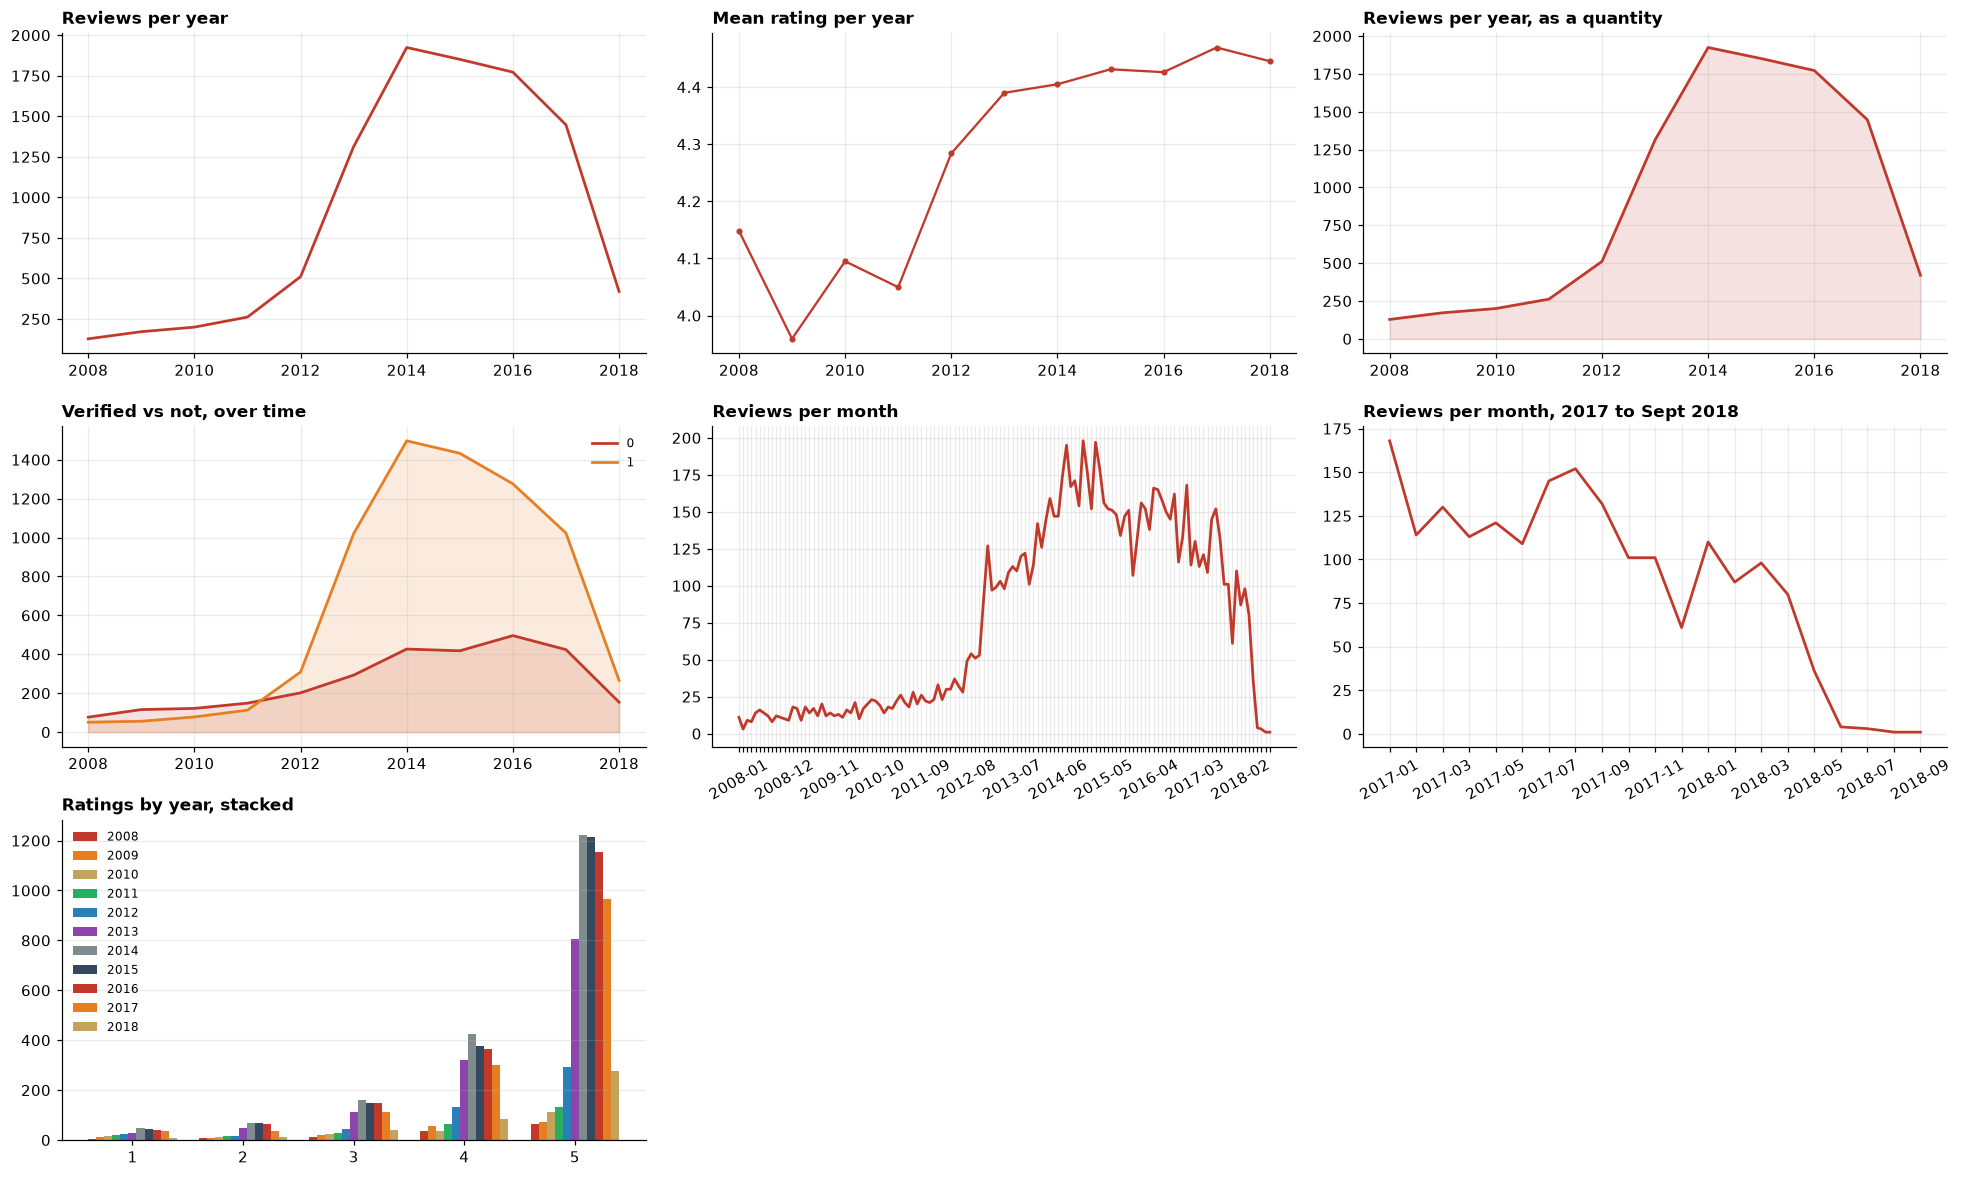

In [11]:
fig(viz.draw_tab(tab, cols=3))

In [12]:
charged = credits_used(ls) - before
print(f"{len(tab.refresh().charts)} charts · credits charged: {charged}")
save_metrics(".", {"notebook": "18_trend", "task": "time on the axis · 4 shapes, 5 grains, the filter that freezes",
                   "model": "—", "project_id": p.id, "credits_charged_this_run": charged,
                   "headline": {"charts_built": len(tab.charts), "months": len(s),
                                "days_in_data": rows[-1]["points"], "peak_month": f"{s.idxmax():%Y-%m}",
                                "last_n_days_90_points": a["n_groups"]}})

7 charts · credits charged: 0
wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- [19 · Part of a whole](../19_composition/) — pie, donut, funnel, treemap, heatmap, matrix, KPI, combo
- [07 · Forecast](../07_forecast_review_volume/) — the same series, forecast without training
- [21 · Measures and filters](../21_measures_and_filters/) — the filter set in full